Dataset Shape:
(9551, 21)

Columns:
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

First 5 Rows:
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Ma

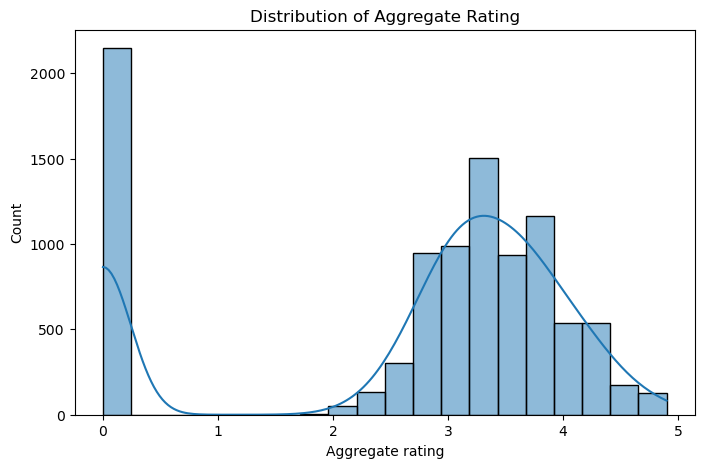

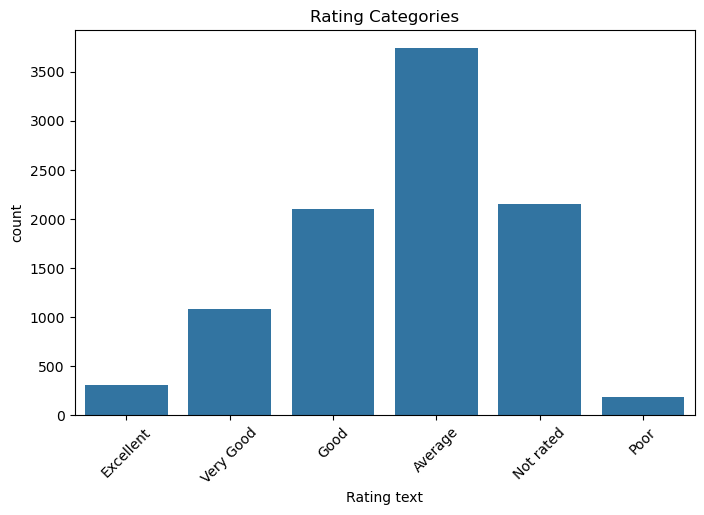


Task 1 Completed


In [19]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("Dataset .csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

# First 5 Rows
print("\nFirst 5 Rows:")
print(df.head())

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Data Types
print("\nData Types:")
print(df.dtypes)

# Fill Missing Cuisines with Unknown
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

# Check Missing Values Again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# Aggregate Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True)
plt.savefig("graph1.png",dpi=300,bbox_inches="tight")
plt.title("Distribution of Aggregate Rating")
plt.show()

# Count Plot
plt.figure(figsize=(8,5))
sns.countplot(x='Rating text', data=df)
plt.savefig("graph2.png",dpi=300,bbox_inches="tight")
plt.title("Rating Categories")
plt.xticks(rotation=45)
plt.show()

print("\nTask 1 Completed")

       Restaurant ID  Country Code    Longitude     Latitude  \
count   9.551000e+03   9551.000000  9551.000000  9551.000000   
mean    9.051128e+06     18.365616    64.126574    25.854381   
std     8.791521e+06     56.750546    41.467058    11.007935   
min     5.300000e+01      1.000000  -157.948486   -41.330428   
25%     3.019625e+05      1.000000    77.081343    28.478713   
50%     6.004089e+06      1.000000    77.191964    28.570469   
75%     1.835229e+07      1.000000    77.282006    28.642758   
max     1.850065e+07    216.000000   174.832089    55.976980   

       Average Cost for two  Price range  Aggregate rating         Votes  
count           9551.000000  9551.000000       9551.000000   9551.000000  
mean            1199.210763     1.804837          2.666370    156.909748  
std            16121.183073     0.905609          1.516378    430.169145  
min                0.000000     1.000000          0.000000      0.000000  
25%              250.000000     1.000000        

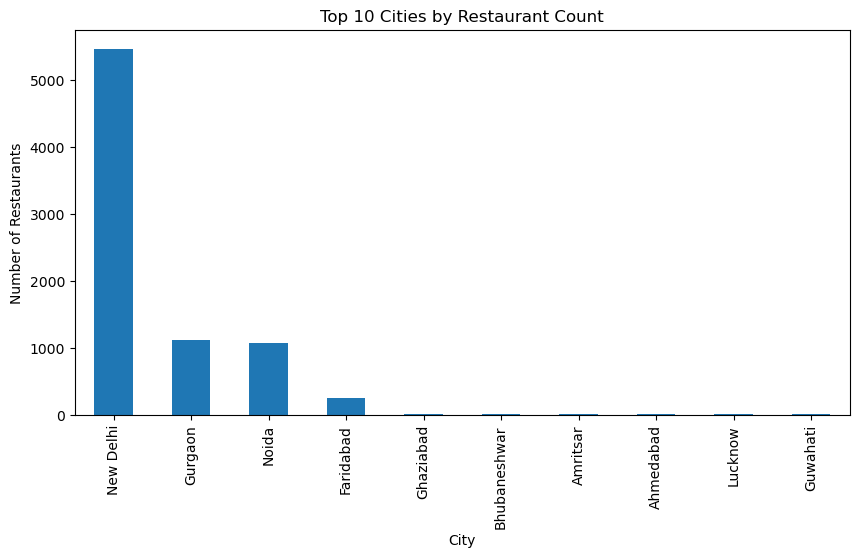

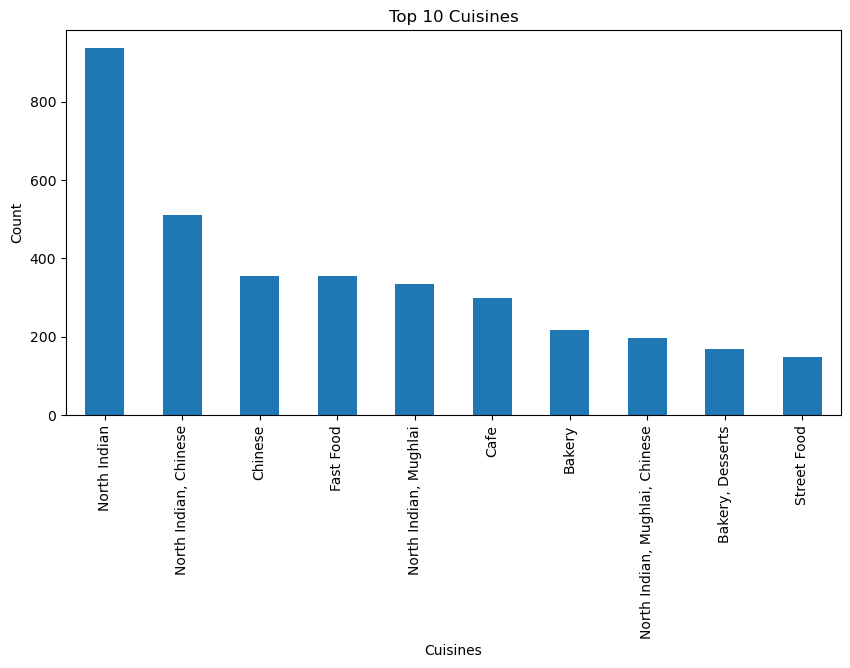


Task 2 Completed


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset .csv")

# Statistical Summary
print(df.describe())

# Country Distribution
print("\nTop Countries:")
print(df['Country Code'].value_counts().head(10))

# Top Cities
print("\nTop Cities:")
print(df['City'].value_counts().head(10))

# Top Cuisines
print("\nTop Cuisines:")
print(df['Cuisines'].value_counts().head(10))

# Top Cities Visualization
plt.figure(figsize=(10,5))
df['City'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Cities by Restaurant Count")
plt.savefig("graph3.png",dpi=300,bbox_inches="tight")
plt.ylabel("Number of Restaurants")
plt.show()

# Top Cuisines Visualization
plt.figure(figsize=(10,5))
df['Cuisines'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Cuisines")
plt.savefig("graph4.png",dpi=300,bbox_inches="tight")
plt.ylabel("Count")
plt.show()

print("\nTask 2 Completed")

In [16]:
!pip install folium


  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)

   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



Map Saved as restaurant_map.html


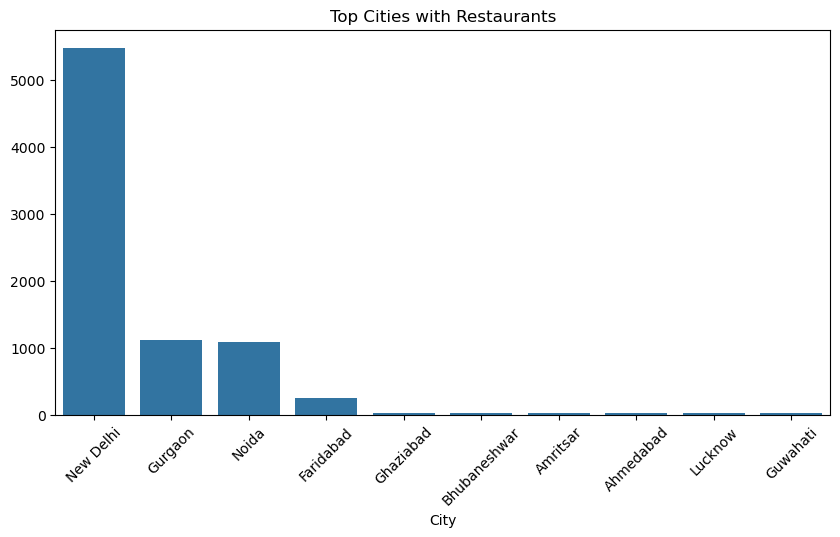

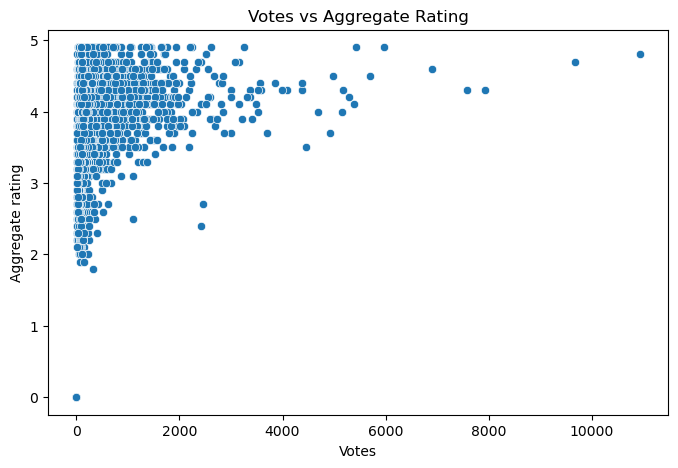


Correlation Matrix:
                  Latitude  Longitude  Aggregate rating
Latitude          1.000000   0.043207          0.000516
Longitude         0.043207   1.000000         -0.116818
Aggregate rating  0.000516  -0.116818          1.000000


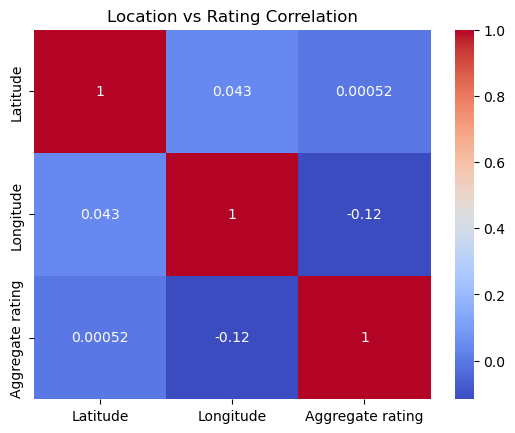


Task 3 Completed


In [18]:
import pandas as pd
import folium
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset .csv")

# Create Map
restaurant_map = folium.Map(
    location=[df['Latitude'].mean(),
              df['Longitude'].mean()],
    zoom_start=5
)

# Add First 100 Restaurants
for i in range(min(100, len(df))):
    folium.Marker(
        [df.iloc[i]['Latitude'],
         df.iloc[i]['Longitude']],
        popup=df.iloc[i]['Restaurant Name']
    ).add_to(restaurant_map)

# Save Map
restaurant_map.save("restaurant_map.html")

print("Map Saved as restaurant_map.html")

# Restaurants by City
city_counts = df['City'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=city_counts.index,
            y=city_counts.values)

plt.xticks(rotation=45)
plt.title("Top Cities with Restaurants")
plt.show()

# Rating vs Votes Correlation
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Votes',
    y='Aggregate rating',
    data=df
)

plt.title("Votes vs Aggregate Rating")
plt.show()

# Correlation
corr = df[['Latitude',
           'Longitude',
           'Aggregate rating']].corr()

print("\nCorrelation Matrix:")
print(corr)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Location vs Rating Correlation")
plt.show()

print("\nTask 3 Completed")